# Agentic RAG with LangGraph

## Learning Objectives

By the end of this notebook, you will:
1. Understand the difference between **Classic RAG** and **Agentic RAG**
2. Build a RAG system that **decides** when to retrieve documents
3. Implement **document grading** to assess retrieval quality
4. Create a **query rewriting** loop for failed retrievals

---

## Prerequisites

This notebook builds on:
- `01_RAG_with_Langchain.ipynb` - Classic RAG implementation
- `01_Intro_to_LangGraph.ipynb` - LangGraph fundamentals

## Step 0: Install Dependencies

In [1]:
!uv pip install -q langgraph langchain langchain-openai langchain-community faiss-cpu pypdf python-dotenv

## Step 1: Setup & Configuration

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

# For Colab: uncomment and add your key
# os.environ["OPENAI_API_KEY"] = "your-key-here"

if os.getenv("OPENAI_API_KEY"):
    print("✅ OPENAI_API_KEY loaded")
else:
    print("⚠️ OPENAI_API_KEY not found")

✅ OPENAI_API_KEY loaded


---

## Part 1: Classic RAG vs Agentic RAG

### Classic RAG (What You've Learned)

In your previous RAG notebooks, the flow was:

```
Query → Retrieve → Generate Answer
```

This works well but has limitations:
- **Always retrieves** even for simple questions ("What is 2+2?")
- **No quality check** on retrieved documents
- **One-shot** retrieval - if results are poor, no recovery

### Agentic RAG (What We'll Build)

An agentic approach adds **decision-making**:

```
         ┌─────────────────────────────────────────────────────┐
         │                                                     │
Query → [Decide: Retrieve?] → [Retrieve] → [Grade Docs] ──────┤
              │                                 │              │
              │ (No retrieval needed)           │ (Docs good)  │ (Docs bad)
              ▼                                 ▼              ▼
         [Generate Answer] ◄────────────── [Generate]    [Rewrite Query]┐
                                                                        │
                                                               └────────┘
```

**Key improvements:**
1. Agent decides *if* retrieval is needed
2. Documents are graded for relevance
3. Failed retrievals trigger query rewriting

---

## Part 2: Setup the RAG Components

First, let's create our vector store using the same PDFs from your RAG demos.

In [4]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
import os

# Path to existing PDFs (reusing from rag_demo)
pdf_folder = "../rag_demo/pdfs"

# Load documents
all_docs = []
pdf_files = [f for f in os.listdir(pdf_folder) if f.endswith('.pdf')]

print(f"📚 Found {len(pdf_files)} PDF files")

for pdf_file in pdf_files[:3]:  # Load first 3 for demo
    pdf_path = os.path.join(pdf_folder, pdf_file)
    loader = PyPDFLoader(pdf_path)
    docs = loader.load()
    all_docs.extend(docs)
    print(f"   ✓ Loaded {pdf_file}: {len(docs)} pages")

# Split documents
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)
splits = text_splitter.split_documents(all_docs)
print(f"\n📄 Created {len(splits)} text chunks")

# Create vector store
embeddings = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(splits, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print("\n✅ Vector store created!")

📚 Found 9 PDF files
   ✓ Loaded 1901.09069v2.pdf: 11 pages
   ✓ Loaded 1508.07909v5.pdf: 11 pages
   ✓ Loaded 2104.09864v5.pdf: 14 pages

📄 Created 317 text chunks

✅ Vector store created!


### Initialize LLM

In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print("✅ LLM initialized")

✅ LLM initialized


---

## Part 3: Define the Agentic RAG State

Unlike the simple `MessagesState`, our Agentic RAG needs to track more information.

In [6]:
from typing import TypedDict, List, Annotated, Literal
from langchain_core.documents import Document

class AgenticRAGState(TypedDict):
    """State for our Agentic RAG system."""
    
    # The user's original question
    question: str
    
    # The current query (may be rewritten)
    query: str
    
    # Retrieved documents
    documents: List[Document]
    
    # Generated answer
    answer: str
    
    # Decision: should we retrieve?
    needs_retrieval: bool
    
    # Grading result: are docs relevant?
    docs_relevant: bool
    
    # Retry counter
    retry_count: int

print("✅ State schema defined")

✅ State schema defined


---

## Part 4: Define the Graph Nodes

Each node is a function that receives state and returns state updates.

### Node 1: Retrieval Decision

This node decides if we need to retrieve documents or can answer directly.

In [7]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def decide_retrieval(state: AgenticRAGState) -> AgenticRAGState:
    """Decide if we need to retrieve documents."""
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a retrieval decision assistant.
Analyze the question and decide if it requires searching a knowledge base about AI/ML research papers.

Answer 'YES' if the question:
- Asks about specific research, papers, or technical concepts
- Needs factual information from documents
- References specific methods, architectures, or findings

Answer 'NO' if the question:
- Is a simple greeting or general question
- Can be answered from general knowledge
- Is a math calculation or simple factual query

Respond with only 'YES' or 'NO'."""),
        ("human", "Question: {question}")
    ])
    
    chain = prompt | llm | StrOutputParser()
    result = chain.invoke({"question": state["question"]})
    
    needs_retrieval = result.strip().upper() == "YES"
    
    print(f"\n🤔 Decision: {'Retrieve documents' if needs_retrieval else 'Answer directly'}")
    
    return {
        "needs_retrieval": needs_retrieval,
        "query": state["question"]  # Initialize query with original question
    }

### Node 2: Retrieve Documents

In [8]:
def retrieve_documents(state: AgenticRAGState) -> AgenticRAGState:
    """Retrieve documents from the vector store."""
    
    query = state["query"]
    docs = retriever.invoke(query)
    
    print(f"\n📚 Retrieved {len(docs)} documents for query: '{query[:50]}...'")
    for i, doc in enumerate(docs):
        print(f"   Doc {i+1}: {doc.page_content[:100]}...")
    
    return {"documents": docs}

### Node 3: Grade Documents

This is a key agentic feature - the system evaluates if retrieved documents are actually useful.

In [9]:
def grade_documents(state: AgenticRAGState) -> AgenticRAGState:
    """Grade documents for relevance to the question."""
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a document relevance grader.
Given a question and a set of documents, determine if the documents contain information relevant to answering the question.

Consider:
- Do the documents discuss topics related to the question?
- Is there enough information to formulate an answer?
- Are the documents on-topic or tangentially related?

Respond with only 'RELEVANT' or 'NOT_RELEVANT'."""),
        ("human", """Question: {question}

Documents:
{documents}

Are these documents relevant?""")
    ])
    
    # Format documents
    docs_text = "\n\n".join([f"[Doc {i+1}]: {doc.page_content}" 
                             for i, doc in enumerate(state["documents"])])
    
    chain = prompt | llm | StrOutputParser()
    result = chain.invoke({
        "question": state["question"],
        "documents": docs_text
    })
    
    docs_relevant = "RELEVANT" in result.upper()
    
    print(f"\n📊 Grading: Documents are {'relevant ✅' if docs_relevant else 'not relevant ❌'}")
    
    return {"docs_relevant": docs_relevant}

### Node 4: Rewrite Query

If documents aren't relevant, we reformulate the query and try again.

In [10]:
def rewrite_query(state: AgenticRAGState) -> AgenticRAGState:
    """Rewrite the query to improve retrieval."""
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a query rewriting assistant.
The original query did not retrieve relevant documents.
Rewrite the query to be more specific, use different keywords, or approach the question from a different angle.

Return only the rewritten query, nothing else."""),
        ("human", """Original question: {question}
Previous query that failed: {query}

Rewritten query:""")
    ])
    
    chain = prompt | llm | StrOutputParser()
    new_query = chain.invoke({
        "question": state["question"],
        "query": state["query"]
    })
    
    new_retry_count = state.get("retry_count", 0) + 1
    
    print(f"\n🔄 Query rewritten (attempt {new_retry_count}):")
    print(f"   Old: {state['query']}")
    print(f"   New: {new_query}")
    
    return {
        "query": new_query,
        "retry_count": new_retry_count
    }

### Node 5: Generate Answer

In [11]:
def generate_answer(state: AgenticRAGState) -> AgenticRAGState:
    """Generate the final answer."""
    
    # Check if we have documents to use
    if state.get("documents") and state.get("docs_relevant", True):
        # RAG-based answer
        prompt = ChatPromptTemplate.from_messages([
            ("system", """You are a helpful AI assistant answering questions based on provided documents.
Use the documents to answer the question. If the documents don't contain enough information, say so.
Be concise and accurate."""),
            ("human", """Question: {question}

Documents:
{documents}

Answer:""")
        ])
        
        docs_text = "\n\n".join([f"{doc.page_content}" for doc in state["documents"]])
        
        chain = prompt | llm | StrOutputParser()
        answer = chain.invoke({
            "question": state["question"],
            "documents": docs_text
        })
    else:
        # Direct answer (no retrieval)
        prompt = ChatPromptTemplate.from_messages([
            ("system", "You are a helpful AI assistant. Answer the question directly and concisely."),
            ("human", "{question}")
        ])
        
        chain = prompt | llm | StrOutputParser()
        answer = chain.invoke({"question": state["question"]})
    
    print(f"\n💬 Answer generated")
    
    return {"answer": answer}

---

## Part 5: Define Routing Functions

These functions determine the flow between nodes.

In [12]:
def route_after_decision(state: AgenticRAGState) -> Literal["retrieve", "generate"]:
    """Route based on retrieval decision."""
    if state.get("needs_retrieval", False):
        return "retrieve"
    return "generate"

def route_after_grading(state: AgenticRAGState) -> Literal["generate", "rewrite"]:
    """Route based on document grading."""
    # Check retry limit (max 2 rewrites)
    if state.get("retry_count", 0) >= 2:
        print("\n⚠️ Max retries reached, generating with available docs")
        return "generate"
    
    if state.get("docs_relevant", False):
        return "generate"
    return "rewrite"

print("✅ Routing functions defined")

✅ Routing functions defined


---

## Part 6: Build the Graph

Now we assemble all components into a LangGraph.

In [13]:
from langgraph.graph import StateGraph, START, END

# Create the graph
workflow = StateGraph(AgenticRAGState)

# Add nodes
workflow.add_node("decide", decide_retrieval)
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("grade", grade_documents)
workflow.add_node("rewrite", rewrite_query)
workflow.add_node("generate", generate_answer)

# Add edges
workflow.add_edge(START, "decide")
workflow.add_conditional_edges("decide", route_after_decision)
workflow.add_edge("retrieve", "grade")
workflow.add_conditional_edges("grade", route_after_grading)
workflow.add_edge("rewrite", "retrieve")  # Retry retrieval
workflow.add_edge("generate", END)

# Compile
agentic_rag = workflow.compile()

print("✅ Agentic RAG graph compiled!")

✅ Agentic RAG graph compiled!


### Visualize the Graph

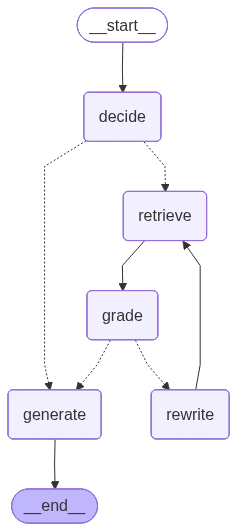

In [14]:
from IPython.display import Image, display

try:
    display(Image(agentic_rag.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph structure:")
    print(agentic_rag.get_graph().draw_mermaid())

---

## Part 7: Testing the Agentic RAG

Let's test with different types of questions.

In [15]:
def ask(question: str):
    """Run the Agentic RAG pipeline."""
    print(f"\n{'='*70}")
    print(f"❓ Question: {question}")
    print(f"{'='*70}")
    
    result = agentic_rag.invoke({
        "question": question,
        "query": "",
        "documents": [],
        "answer": "",
        "needs_retrieval": False,
        "docs_relevant": False,
        "retry_count": 0
    })
    
    print(f"\n{'='*70}")
    print(f"🎯 Final Answer:")
    print(f"{'='*70}")
    print(result["answer"])
    
    return result

In [16]:
# Test 1: Simple question (should skip retrieval)
ask("What is 2 + 2?")


❓ Question: What is 2 + 2?

🤔 Decision: Answer directly

💬 Answer generated

🎯 Final Answer:
2 + 2 equals 4.


{'question': 'What is 2 + 2?',
 'query': 'What is 2 + 2?',
 'documents': [],
 'answer': '2 + 2 equals 4.',
 'needs_retrieval': False,
 'docs_relevant': False,
 'retry_count': 0}

In [17]:
# Test 2: Research question (should retrieve)
ask("What is Word2Vec and how does it work?")


❓ Question: What is Word2Vec and how does it work?

🤔 Decision: Retrieve documents

📚 Retrieved 3 documents for query: 'What is Word2Vec and how does it work?...'
   Doc 1: toolkit (https://code.google.com/archive/p/word2vec/).
14https://research.fb.com/projects/fasttext/
...
   Doc 2: While research on how to compose word vec-
tors to represent higher-level entities such as sen-
tenc...
   Doc 3: language models, and only after some time (ar-
guably after Collobert and Weston (2008)) has
the bui...

📊 Grading: Documents are relevant ✅

💬 Answer generated

🎯 Final Answer:
Word2Vec is a technique for generating word embeddings, which are dense vector representations of words. It works by leveraging word-context co-occurrence counts in a corpus rather than predicting the next word in a sequence. The method involves creating a word-context matrix that captures how often words appear in similar contexts. This allows for the representation of words in a continuous vector space, facilitatin

{'question': 'What is Word2Vec and how does it work?',
 'query': 'What is Word2Vec and how does it work?',
 'documents': [Document(id='6b46deac-2164-4928-a62f-233e54d4e583', metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-05-03T00:58:57+00:00', 'author': '', 'keywords': '', 'moddate': '2023-05-03T00:58:57+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) kpathsea version 6.3.2', 'subject': '', 'title': '', 'trapped': '/False', 'source': '../rag_demo/pdfs/1901.09069v2.pdf', 'total_pages': 11, 'page': 5, 'page_label': '6'}, page_content='toolkit (https://code.google.com/archive/p/word2vec/).\n14https://research.fb.com/projects/fasttext/\nby training algorithms that predict the next word\ngiven its context (as is the case in language\nmodelling) but by leveraging word-context co-\noccurrence counts globally in a corpus. These are\nvery often represented (Turney and Pantel (2010))\nas word-context matr

In [18]:
# Test 3: Technical question about embeddings
ask("Explain the difference between CBOW and Skip-gram models.")


❓ Question: Explain the difference between CBOW and Skip-gram models.

🤔 Decision: Retrieve documents

📚 Retrieved 3 documents for query: 'Explain the difference between CBOW and Skip-gram ...'
   Doc 1: A little later, in 2013b and 2013c, Mikolov
et al. have introduced two models for learning
embedding...
   Doc 2: Deep
Neural Net,
Negative
Sampling
First time a model was built primarily to
output just embeddings....
   Doc 3: based upon its context, in SG the roles are re-
versed, and the centre word is, instead, used to
pre...

📊 Grading: Documents are relevant ✅

💬 Answer generated

🎯 Final Answer:
The main difference between the Continuous Bag-of-Words (CBOW) and Skip-gram (SG) models lies in their predictive approach. CBOW predicts the target word based on its surrounding context words, while Skip-gram predicts the context words given a target word. Both models are log-linear and utilize a two-step training procedure, but they differ in the loss function used for updates. Additi

{'question': 'Explain the difference between CBOW and Skip-gram models.',
 'query': 'Explain the difference between CBOW and Skip-gram models.',
 'documents': [Document(id='debd6698-7d55-4d20-af80-38b163d47115', metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-05-03T00:58:57+00:00', 'author': '', 'keywords': '', 'moddate': '2023-05-03T00:58:57+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) kpathsea version 6.3.2', 'subject': '', 'title': '', 'trapped': '/False', 'source': '../rag_demo/pdfs/1901.09069v2.pdf', 'total_pages': 11, 'page': 5, 'page_label': '6'}, page_content='A little later, in 2013b and 2013c, Mikolov\net al. have introduced two models for learning\nembeddings, namely the continuous bag-of-words\n(CBOW) and skip-gram ( SG) models. Both of\nthese models are log-linear models (as seen in\nprevious works) and use the two-step procedure\n(Mikolov et al. (2009)) for training. The main dif

In [19]:
# Test 4: Question that might need query rewriting
ask("How do neural networks learn word meanings?")


❓ Question: How do neural networks learn word meanings?

🤔 Decision: Retrieve documents

📚 Retrieved 3 documents for query: 'How do neural networks learn word meanings?...'
   Doc 1: analysis shows that the neural networks are able to
learn compounding and transliteration from sub-
...
   Doc 2: network language models (NNLMs). Using a con-
cept called importance sampling (Doucet (2001)),
they ...
   Doc 3: The history of NNLMs, which started with the
ﬁrst large neural language model (Bengio et al.
(2003))...

📊 Grading: Documents are relevant ✅

💬 Answer generated

🎯 Final Answer:
Neural networks learn word meanings by utilizing sub-word representations, which allow them to understand compounding and transliteration. They employ techniques like importance sampling to efficiently estimate gradients and bypass costly normalization factors, leading to significant improvements in training time and performance. This approach enables neural networks to model language more effectively than 

{'question': 'How do neural networks learn word meanings?',
 'query': 'How do neural networks learn word meanings?',
 'documents': [Document(id='175d2f22-fee8-4a31-9f40-d9186afd5370', metadata={'producer': 'GPL Ghostscript GIT PRERELEASE 9.08', 'creator': 'dvips(k) 5.991 Copyright 2011 Radical Eye Software', 'creationdate': '2016-06-13T01:31:02-04:00', 'moddate': '2016-06-13T01:31:02-04:00', 'title': 'arXiv:1508.07909v5  [cs.CL]  10 Jun 2016', 'source': '../rag_demo/pdfs/1508.07909v5.pdf', 'total_pages': 11, 'page': 0, 'page_label': '1'}, page_content='analysis shows that the neural networks are able to\nlearn compounding and transliteration from sub-\nword representations.\nThis paper has two main contributions:\n• We show that open-vocabulary neural ma-'),
  Document(id='7babcc7d-7930-4440-a69a-cf88f274771d', metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-05-03T00:58:57+00:00', 'author': '', 'keywords': '', 'moddate': '2023-05-03T00:58

---

## Part 8: Classic vs Agentic RAG Comparison

| Aspect | Classic RAG | Agentic RAG |
|--------|-------------|-------------|
| **Retrieval** | Always retrieves | Decides if needed |
| **Quality Check** | None | Documents graded |
| **Failure Handling** | One-shot | Query rewriting loop |
| **Latency** | Fixed (1 retrieval) | Variable (may loop) |
| **Cost** | Consistent | Varies with complexity |
| **Accuracy** | Good | Often better |

### When to Use Each

**Use Classic RAG when:**
- All questions need document context
- Latency is critical
- Cost optimization is priority

**Use Agentic RAG when:**
- Questions vary in complexity
- Accuracy is paramount
- You can tolerate variable latency

---

## 🎯 Student Challenge

### Challenge 1: Add a Hallucination Check

Create a new node `check_hallucination` that verifies the answer is grounded in the retrieved documents. If hallucination is detected, regenerate with stricter prompting.

```python
def check_hallucination(state: AgenticRAGState) -> AgenticRAGState:
    """Check if the answer is grounded in documents."""
    # Your code here
    pass
```

### Challenge 2: Add Confidence Scoring

Modify the `generate_answer` node to also output a confidence score (0-100). Add this to the state and display it in results.

### Challenge 3: Hybrid Search

Modify the `retrieve_documents` node to try keyword search if vector search returns no relevant results.

In [ ]:
# Your solution for Challenge 1:



In [ ]:
# Your solution for Challenge 2:



In [ ]:
# Your solution for Challenge 3:



---

## Summary

In this notebook, you built an **Agentic RAG** system that:

1. ✅ **Decides** if retrieval is needed
2. ✅ **Grades** retrieved documents for relevance
3. ✅ **Rewrites** queries when results are poor
4. ✅ Uses **LangGraph** for explicit, debuggable control flow

This pattern extends naturally to more complex scenarios:
- Multi-source retrieval (web + documents + databases)
- Multi-agent collaboration
- Human-in-the-loop verification

**Key insight**: Agentic systems treat AI as a **decision-maker**, not just a text generator. The graph makes these decisions explicit and controllable.